<a href="https://colab.research.google.com/github/amathe1/GenAI-AgenticAI-Hub/blob/main/iris_data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Overfitting and how to prevent it using below techniques


*   Dropout Layer
*   Early Stopping
*   L2 Regularization




In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris    # it means bring me load_iris method from datasets module inside sklearn library (importing iris data set from Scikit-learn)
from sklearn.model_selection import train_test_split # Existing utility in sklearn used to split data into Train, Test data
from sklearn.preprocessing import StandardScaler # StanardScaler/Z-Scalar normalization technique for data normalization

import matplotlib.pyplot as plt # importing matplotlib for plotting output graph


In [3]:
#Step1 : Load Dataset
data = load_iris()
X = data.data     # load the values of key 'data' from dict 'data'
y = data.target   # load the values of key 'target' from dict 'data'
data = load_iris()

"""
Please see the below keys and the data it contains

{'data': array([[5.1, 3.5, 1.4, 0.2], [Sepal_length, Sepal_width, Petal_length, Petal_width]


'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

        'target_names': array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Here 0 means setosa, 1 means versicolor, 2 means virginica

This is the beauty of using Scikit-learn, BUT in real time we need to preprosess the data.

"""

data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [5]:
#Step2 : Train/Validate split : Splitting the input data for training & testing using train_test_split(), note we mentioned the % of test data size


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.4, random_state=42
)

print(X.shape)
print(y.shape)
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(150, 4)
(150,)
(90, 4)
(60, 4)
(90,)
(60,)


In [7]:
#Step3 : Normalize

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)     # For train data, we use fit_transform() - it will calculate mean, standard deviation
X_val = scaler.transform(X_val)             # For test data, we use transform() - it can't calculate mean & standard deviation as this is unseen data. Hence method name is diff for test.
# type(X_train)
# type(X_val)

# Converting input data into tensor, as o/p from normalization is of type numpy array but NN expect tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)


/tmp/ipython-input-99589197.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
/tmp/ipython-input-99589197.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val = torch.tensor(y_val, dtype=torch.long)


In [8]:
#Part 1 : Overfitting model
class OverfitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,3)
        )

    def forward(self,x):
        return self.net(x)


In [9]:
# Traning function
def train_model(model, optimizer, epochs=200):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        pred = model(X_train)
        loss = criterion(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step() # Adjusting weights & Biases

        model.eval() # Initiating validation
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

        train_losses.append(loss.item()) # Training loss
        val_losses.append(val_loss.item()) # Validation loss

    return train_losses, val_losses


In [10]:
# Train

model1 = OverfitModel()
opt1 = optim.Adam(model1.parameters(), lr=0.01)

train1, val1 = train_model(model1, opt1)


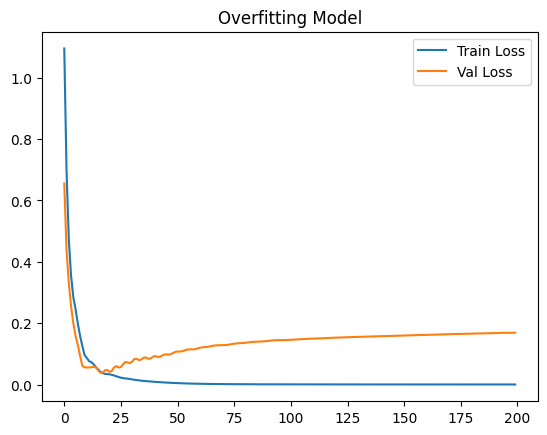

In [11]:
# Visualize overfitting
plt.plot(train1,label="Train Loss")
plt.plot(val1,label="Val Loss")
plt.legend()
plt.title("Overfitting Model")
plt.show()

In [12]:
# Regularize model
# Apply Dropout, L2, Early stopping techniques


class RegularizedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64,3)
        )

    def forward(self,x):
        return self.net(x)

In [13]:
# Early stopping Training
def train_with_early_stopping(model, optimizer, patience=15):
    criterion = nn.CrossEntropyLoss()

    best_loss = float('inf')
    counter = 0

    train_losses, val_losses = [], []

    for epoch in range(300):
        model.train()
        pred = model(X_train)
        loss = criterion(pred,y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        val_pred = model(X_val)
        val_loss = criterion(val_pred,y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

    return train_losses,val_losses

In [14]:
# L2 via Weight Decay

model2 = RegularizedModel()
opt2 = optim.Adam(model2.parameters(), lr=0.01, weight_decay=1e-3)

train2, val2 = train_with_early_stopping(model2, opt2)


Early stopping triggered


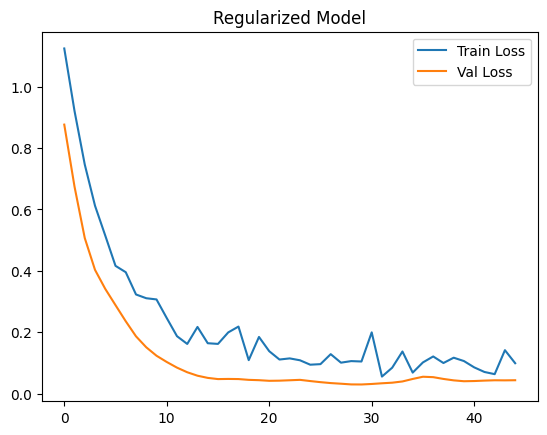

In [15]:
# Visualize after fix
plt.plot(train2,label="Train Loss")
plt.plot(val2,label="Val Loss")
plt.legend()
plt.title("Regularized Model")
plt.show()